In [74]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle as pkl

In [75]:
# load data

In [76]:
location = 'D:/personal/phD/code/information-decomposition/ibl-partial-info-decomp/data/interim/'

In [ ]:
x = location+'07dc4b76-5b93-4a03-82a0-b3d9cc73f412_stim_qe_neuron_True_False_group_false.pkl'
with open(x,'rb') as f:
    d = pkl.load(f)

dict_keys(['SCm', 'MRN'])

In [77]:
# so for non-grouped ones
# region, neurons
# set negative values to zero
# then do a nanmean

# for grouped

In [101]:
# for each condition, group animals together -> this makes sense

# now for group==false
def load_data(location, eid, epoch, normalization_params, group):
    normalization = '_'.join(str(value) for value in normalization_params.values())
    if group:
        variable='group_true'
    else:
        variable='group_false'
    uuid = eid + '_'+ epoch + '_'+ normalization + '_' + variable
    filename = f'{location}/{uuid}.pkl'
    with open(filename,'rb') as f:
        data = pkl.load(f)
    

    # now compute mean and return
    if group==False:
        mean_data = {}
        std_data = {}
        for k in data.keys():
            if len(data[k])==0:
                continue
            else:
                x = data[k]    
                means = np.nanmean(x, axis=0)
                stds = np.nanstd(x, axis=0)
                mean_data[k] = means
                std_data[k] = stds
        return mean_data, std_data, data
    else:
        return data

In [81]:
normalization_params = {'run_correction':'qe', 'normalization':'neuron', 'drop':True, 'mi_calculation':False}

In [147]:
# NOTE:just see how it goes, maybe have less strict criteria, or no MI criteria for now

In [80]:
list_of_eids = np.load('D:\\personal\\phD\\code\\information-decomposition\\ibl-partial-info-decomp\\data\\processed\\eids_with_detailed_insertions_v3.npy',allow_pickle=True)

In [150]:

# also mark important ones for each epoch

stim_regions_imp = np.asarray(['VISpm', 'PRNc', 'IP', 'VISli', 'VM', 'SCm', 'GRN', 'LGv', 'VISam','PB'])
choice_regions_imp = np.asarray(['PRNc', 'GRN', 'VM', 'IP', 'APN', 'PPN', 'VISpm', 'GPe', 'DCO','PL'])
fback_regions_imp = np.asarray(['PPN', 'AUDp', 'PAG', 'PRNc', 'IC', 'AUDv', 'GRN', 'IP', 'MRN','RN'])

important_regions_per_epoch = {}
important_regions_per_epoch['stim'] = stim_regions_imp
important_regions_per_epoch['choice'] = choice_regions_imp
important_regions_per_epoch['feedback'] = fback_regions_imp

In [169]:
def collate_plot_data(data_mean):
    plot_data = {}
    for x in data_mean.keys():
        # compute means how
        d = data_mean[x]
        mean = np.mean(d, axis=0)
        std = np.std(d, axis=0)
        plot_data[x] = [mean, std]
    return plot_data

def organize_data_for_plotting(df_epoch_mean):
    redundnacy_means = []
    synergy_means = []
    trivariatemi_means = []
    redundnacy_stds = []
    synergy_stds = []
    trivariatemi_stds = []
    decoding_mean = []
    decoding_std = []
    labels = np.asarray(list(df_epoch_mean.keys()))
    for l in labels:
        u1, u2, red, syn,mi_yx1, mi_yx2, coinfo, mi_yx1x2,decoding = df_epoch_mean[l][0]
        redundnacy_means.append(red)
        synergy_means.append(syn)
        trivariatemi_means.append(mi_yx1x2)
        decoding_mean.append(decoding)

        u1, u2, red, syn,mi_yx1, mi_yx2, coinfo, mi_yx1x2,decoding = df_epoch_mean[l][1]
        redundnacy_stds.append(red)
        synergy_stds.append(syn)
        trivariatemi_stds.append(mi_yx1x2)
        decoding_std.append(decoding)

    redundnacy_means = np.asarray(redundnacy_means)
    synergy_means = np.asarray(synergy_means)
    trivariatemi_means = np.asarray(trivariatemi_means)
    redundnacy_stds = np.asarray(redundnacy_stds)
    synergy_stds = np.asarray(synergy_stds)
    trivariatemi_stds = np.asarray(trivariatemi_stds)

    decoding_means = np.asarray(decoding_mean)
    decoding_stds = np.asarray(decoding_std)

    return redundnacy_means,synergy_means,trivariatemi_means,redundnacy_stds,synergy_stds,trivariatemi_stds, decoding_means, decoding_stds


In [157]:
def plot_syn_red(list_of_eids, epoch, epoch_important):
    epoch_mean, epoch_std = compute_means(list_of_eids, epoch) 
    df_epoch_mean = collate_plot_data(epoch_mean)
    redundnacy_means,synergy_means,trivariatemi_means,redundnacy_stds,synergy_stds,trivariatemi_stds = organize_data_for_plotting(df_epoch_mean)
    labels = np.asarray(list(df_epoch_mean.keys()))
    top = []
    important = epoch_important[epoch]
    for idx,l in enumerate(labels):
        if l in important:
            top.append(idx)
    N = len(labels)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(np.arange(N)-0.3, redundnacy_means, width=0.3, yerr=redundnacy_stds/2,label='redundancy',alpha=0.75, edgecolor='k')
    ax.bar(np.arange(N), synergy_means, width=0.3, yerr=synergy_stds/2,label='synergy',alpha=0.75, edgecolor='k')
    # ax.bar(np.arange(N)+0.3, trivariatemi_means, width=0.3, yerr=trivariatemi_stds/2)
    ax.set_xticks(np.arange(N)-0.15, labels, rotation=90)
    xticks = plt.gca().get_xticklabels()
    for i in top:
        xticks[i].set_color('red')  # Change color of specified labels to red
    ax.legend()
    ax.set_title(f'{epoch}')


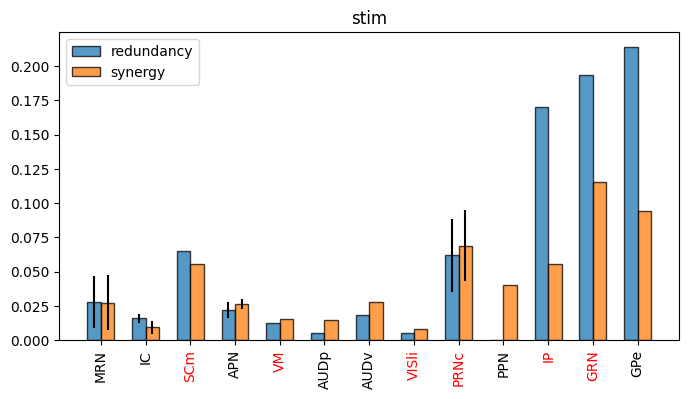

In [158]:
plot_syn_red(list_of_eids, 'stim', important_regions_per_epoch)

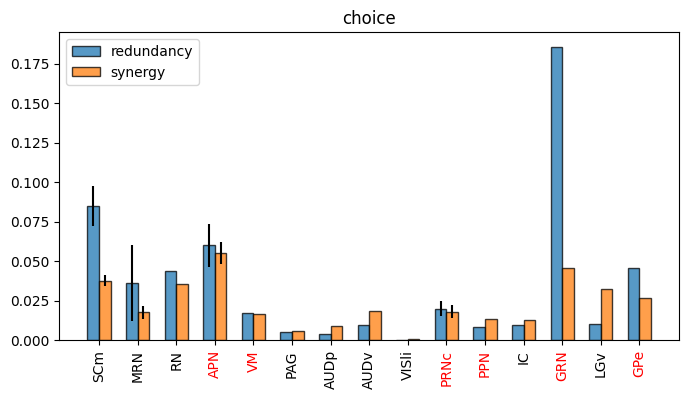

In [159]:
plot_syn_red(list_of_eids, 'choice', important_regions_per_epoch)

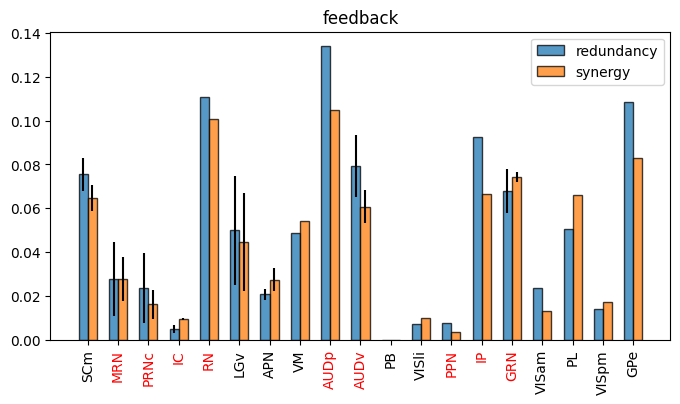

In [160]:
plot_syn_red(list_of_eids, 'feedback', important_regions_per_epoch)

In [1]:
# plot decoder performance

In [82]:
normalization_params = {'run_correction':'qe', 'normalization':'neuron', 'drop':True, 'mi_calculation':False}

In [162]:
# for each condition, group animals together -> this makes sense


def load_decoding_data(location, eid, epoch, normalization_params, group):
    normalization = '_'.join(str(value) for value in normalization_params.values())
    if group:
        variable='group_true'
    else:
        variable='group_false'
    uuid = eid + '_'+ epoch + '_'+ normalization + '_' + variable
    filename = f'{location}/{uuid}.pkl'
    with open(filename,'rb') as f:
        data = pkl.load(f)
    

    # now compute mean and return
    if group==False:
        mean_data = {}
        std_data = {}
        for k in data.keys():
            if len(data[k])==0:
                continue
            else:
                decoder_performance = data[k][:,-1]
                keep_idx = np.where(decoder_performance>0)[0]
                if len(keep_idx)==0:
                    print(f"{eid}, {data[k].shape}, {np.max(data[k][:,-1])}, {k}")
                    continue
                x = data[k][keep_idx, :] # keep only instances where decoder performace is greater than 0   
                means = np.nanmean(x, axis=0)
                stds = np.nanstd(x, axis=0)
                mean_data[k] = means
                std_data[k] = stds
        return mean_data, std_data, data
    else:
        return data

In [163]:
def compute_means(list_of_eids, epoch):
    normalization_params = {'run_correction':'qe', 'normalization':'neuron', 'drop':True, 'mi_calculation':False}
    data_mean = {}
    data_std = {}

    for eid in list_of_eids:
        mean, std, _ = load_decoding_data(location, eid, epoch, normalization_params, False)
        for k in mean.keys():
            if k in data_mean.keys():
                x = data_mean[k]
                x.append(mean[k])
                data_mean[k] = x
                y = data_std[k]
                y.append(std[k])
                data_std[k] = y
            else:
                x = [mean[k]]
                y = [std[k]]
                data_mean[k] = x
                data_std[k] = y
    
    return data_mean, data_std

In [164]:
epoch_mean, epoch_std = compute_means(list_of_eids, 'stim') 

11163613-a6c9-4975-9586-84dc00481547, (10, 9), -0.619836025074885, PRNc
233617ec-c5cf-4eda-afc8-3b1d94f36d73, (105, 9), -0.47601525884201096, LGv
5386aba9-9b97-4557-abcd-abc2da66b863, (45, 9), -0.604289646184642, VM
6274dda8-3a59-4aa1-95f8-a8a549c46a26, (105, 9), -0.4232972487286645, SCm
7dd27c2f-9544-448d-918d-be0f9837b0e0, (120, 9), -0.5894704924334752, PB
872ce8ff-9fb3-485c-be00-bc5479e0095b, (153, 9), -0.4856541930273252, VISli
97c1d08d-57b4-4595-8052-91eb84ebfd74, (66, 9), -0.531033082891615, PRNc
9a629642-3a9c-42ed-b70a-532db0e86199, (15, 9), -0.32442574816487846, VM
b182b754-3c3e-4942-8144-6ee790926b58, (10, 9), -0.7022341499528872, SCm
bb099402-fb31-4cfd-824e-1c97530a0875, (28, 9), -0.6002610346464167, VISpm
bb099402-fb31-4cfd-824e-1c97530a0875, (28, 9), -0.2028944723296882, SCm
dd4da095-4a99-4bf3-9727-f735077dba66, (36, 9), -0.5782060860595346, VISam
e2b845a1-e313-4a08-bc61-a5f662ed295e, (171, 9), -0.4376806986117332, VISam
f9860a11-24d3-452e-ab95-39e199f20a93, (153, 9), -0.09

In [171]:
epoch_mean, epoch_std = compute_means(list_of_eids, 'stim') 
df_epoch_mean = collate_plot_data(epoch_mean)
redundnacy_means,synergy_means,trivariatemi_means,redundnacy_stds,synergy_stds,trivariatemi_stds,decoding_means, decoding_stds= organize_data_for_plotting(df_epoch_mean)
labels = np.asarray(list(df_epoch_mean.keys()))

11163613-a6c9-4975-9586-84dc00481547, (10, 9), -0.619836025074885, PRNc
233617ec-c5cf-4eda-afc8-3b1d94f36d73, (105, 9), -0.47601525884201096, LGv
5386aba9-9b97-4557-abcd-abc2da66b863, (45, 9), -0.604289646184642, VM
6274dda8-3a59-4aa1-95f8-a8a549c46a26, (105, 9), -0.4232972487286645, SCm
7dd27c2f-9544-448d-918d-be0f9837b0e0, (120, 9), -0.5894704924334752, PB
872ce8ff-9fb3-485c-be00-bc5479e0095b, (153, 9), -0.4856541930273252, VISli
97c1d08d-57b4-4595-8052-91eb84ebfd74, (66, 9), -0.531033082891615, PRNc
9a629642-3a9c-42ed-b70a-532db0e86199, (15, 9), -0.32442574816487846, VM
b182b754-3c3e-4942-8144-6ee790926b58, (10, 9), -0.7022341499528872, SCm
bb099402-fb31-4cfd-824e-1c97530a0875, (28, 9), -0.6002610346464167, VISpm
bb099402-fb31-4cfd-824e-1c97530a0875, (28, 9), -0.2028944723296882, SCm
dd4da095-4a99-4bf3-9727-f735077dba66, (36, 9), -0.5782060860595346, VISam
e2b845a1-e313-4a08-bc61-a5f662ed295e, (171, 9), -0.4376806986117332, VISam
f9860a11-24d3-452e-ab95-39e199f20a93, (153, 9), -0.09

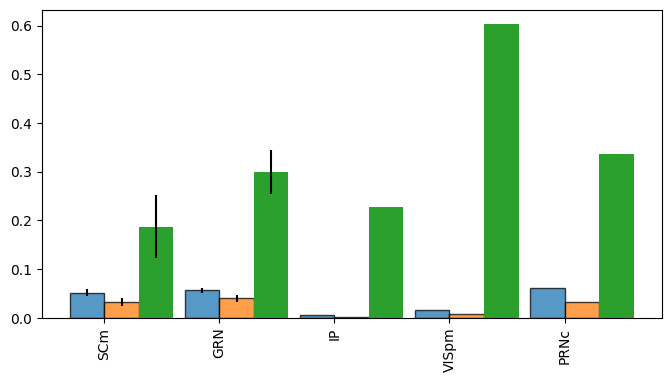

In [172]:
N = len(labels)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(np.arange(N)-0.3, redundnacy_means, width=0.3, yerr=redundnacy_stds/2,label='redundancy',alpha=0.75, edgecolor='k')
ax.bar(np.arange(N), synergy_means, width=0.3, yerr=synergy_stds/2,label='synergy',alpha=0.75, edgecolor='k')
ax.bar(np.arange(N)+0.3, decoding_means, width=0.3, yerr=decoding_stds/2)
ax.set_xticks(np.arange(N)-0.15, labels, rotation=90)

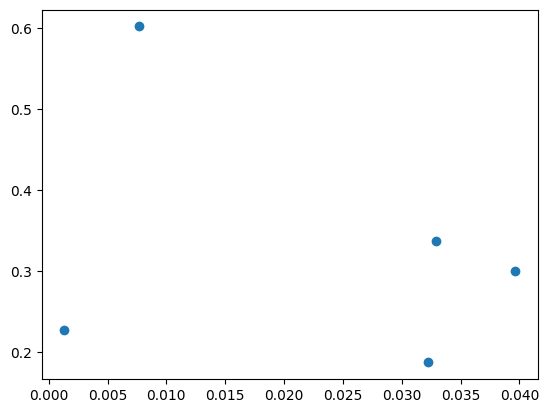

In [174]:
plt.scatter(synergy_means, decoding_means)

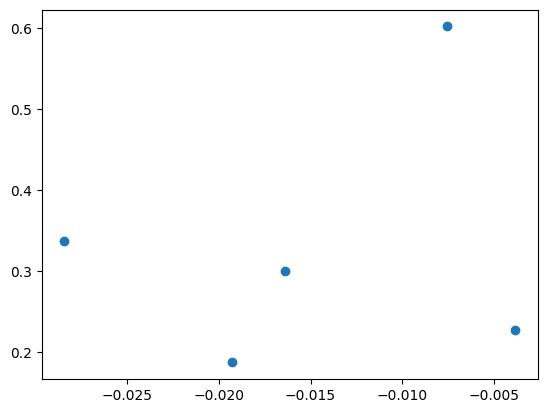

In [176]:
plt.scatter(synergy_means-redundnacy_means, decoding_means)

In [304]:
# don't compute means at all; just collate all the data
# for each condition, group animals together -> this makes sense


def load_animal_data(location, eid, epoch, normalization_params, group, decoder_check=True):
    normalization = '_'.join(str(value) for value in normalization_params.values())
    if group:
        variable='group_true'
    else:
        variable='group_false'
    uuid = eid + '_'+ epoch + '_'+ normalization + '_' + variable
    filename = f'{location}/{uuid}.pkl'
    with open(filename,'rb') as f:
        data = pkl.load(f)
    

    # now compute mean and return
    if group==False:
        animal_data = {}
        std_data = {}
        for k in data.keys():
            if len(data[k])==0:
                continue
            else:
                if decoder_check:
                    decoder_performance = data[k][:,-1]

                    keep_idx = np.where(decoder_performance>0)[0]
                    if len(keep_idx)==0:
                        # print(f"{eid}, {data[k].shape}, {np.max(data[k][:,-1])}, {k}")
                        continue
                    x = data[k][keep_idx, :] # keep only instances where decoder performace is greater than 0   
                else:
                    x = data[k][:]
                animal_data[k] = x
        return animal_data

In [305]:
def group_data_all(list_of_eids, epoch, decoder_check):
    normalization_params = {'run_correction':'qe', 'normalization':'neuron', 'drop':True, 'mi_calculation':False}
    data_mean = {}

    for eid in list_of_eids:
        animal_data = load_animal_data(location, eid, epoch, normalization_params, False, decoder_check)
        for k in animal_data.keys():
            if k in data_mean.keys():
                x = data_mean[k]
                x.append(animal_data[k])
                data_mean[k] = x
            else:
                x = [animal_data[k]]
                data_mean[k] = x
    
    return data_mean

In [327]:
def plot_epoch(list_of_eids, epoch, decoder_check):
    data = group_data_all(list_of_eids, epoch,decoder_check)
    if decoder_check:
        ncols = len(list(data.keys()))
        fig, ax = plt.subplots(figsize=(4*ncols, 4), ncols=ncols,sharex=True, sharey=True)
    else:
        fig, ax = plt.subplots(figsize=(20, 10), ncols=5, nrows=2,sharex=True, sharey=True)
    
    key_list = list(data.keys())
    for ax_idx, _ in enumerate(ax.flatten()):

        k = key_list[ax_idx]
        temp = data[k]

        values_x = []
        values_y = []
        for idx in range(len(temp)):
            # u1, u2, red, syn,mi_yx1, mi_yx2, coinfo, mi_yx1x2,decoding = temp[idx]
            values_x.append(temp[idx][:,6].reshape(-1,))
            values_y.append(temp[idx][:,8].reshape(-1,))

        flat_x = [item for array in values_x for item in array.tolist()]
        flat_y = [item for array in values_y for item in array.tolist()]
        slope, intercept = np.polyfit(flat_x, flat_y, 1)
        line = slope * np.asarray(flat_x) + intercept
        ax.flatten()[ax_idx].scatter(flat_x, flat_y,marker='.')
        ax.flatten()[ax_idx].plot(flat_x, line, color='red',linestyle='dashed')

        ax.flatten()[ax_idx].set_title(f'{k}')
        ax.flatten()[ax_idx].set_xlabel('Synergy-Redundancy')
        ax.flatten()[ax_idx].set_ylabel('Cross-validated accuracy')
        ax.flatten()[ax_idx].axvline(x=0,color='k', alpha=0.5, linestyle='--')
        ax.flatten()[ax_idx].set_ylim([0,1])
        ax.flatten()[ax_idx].axvline(x=0,color='k', alpha=0.5, linestyle='--')
        ax.flatten()[ax_idx].axhline(y=0.5,color='k', alpha=0.5, linestyle='--')
    plt.suptitle(f'{epoch}')    
    plt.tight_layout()
    


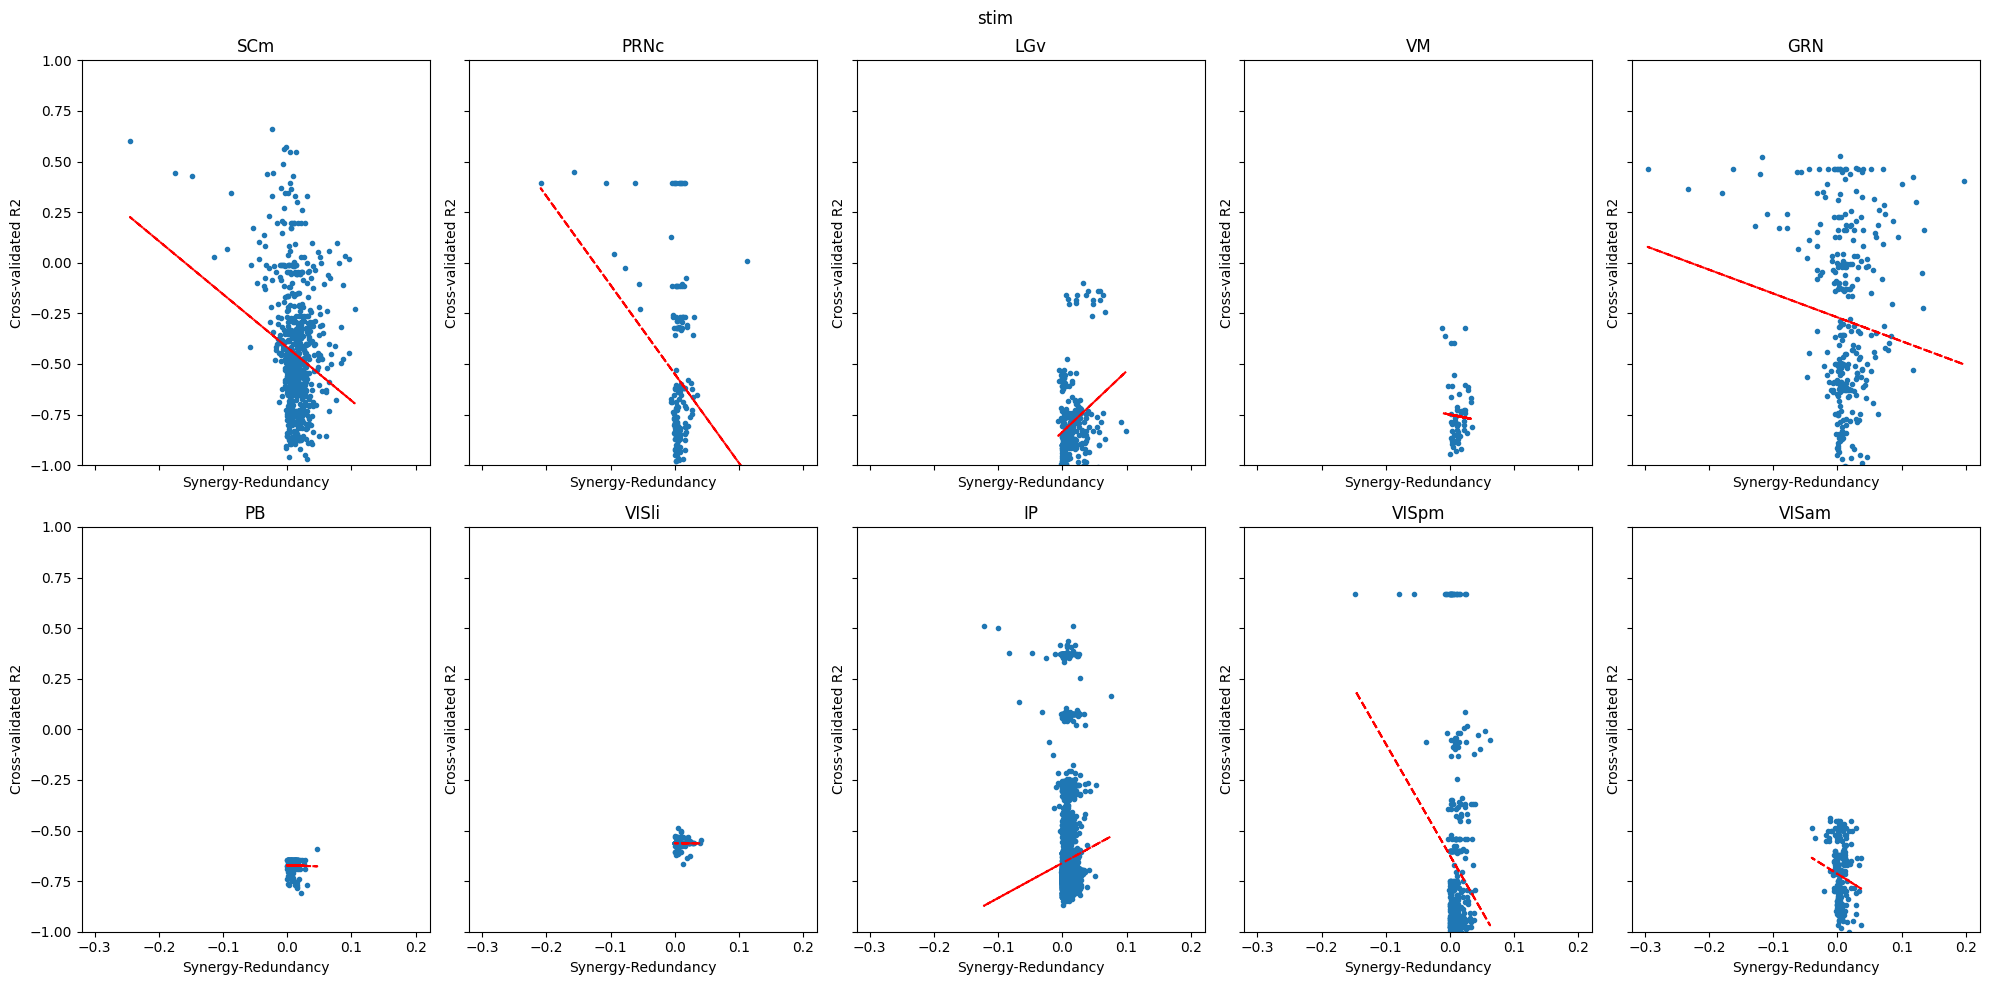

In [258]:
plot_epoch(list_of_eids, 'stim',False)

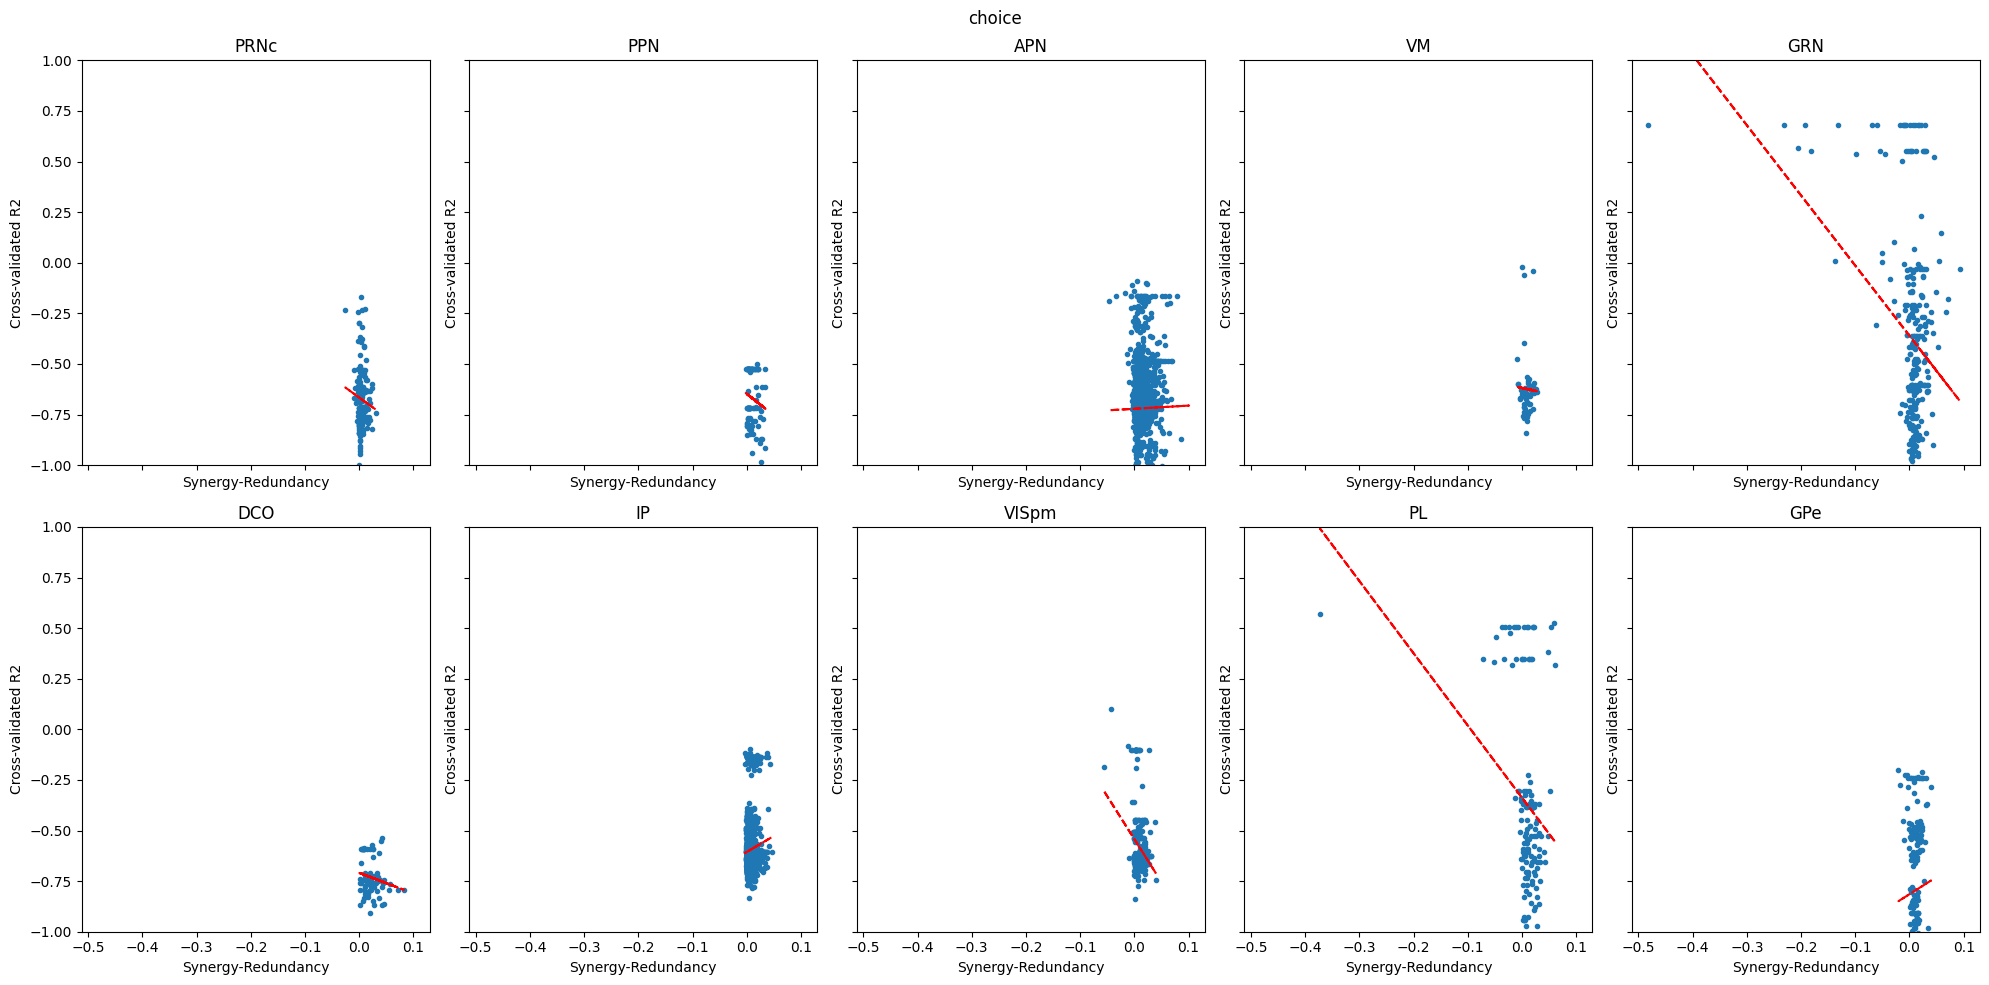

In [260]:
plot_epoch(list_of_eids, 'choice', False)

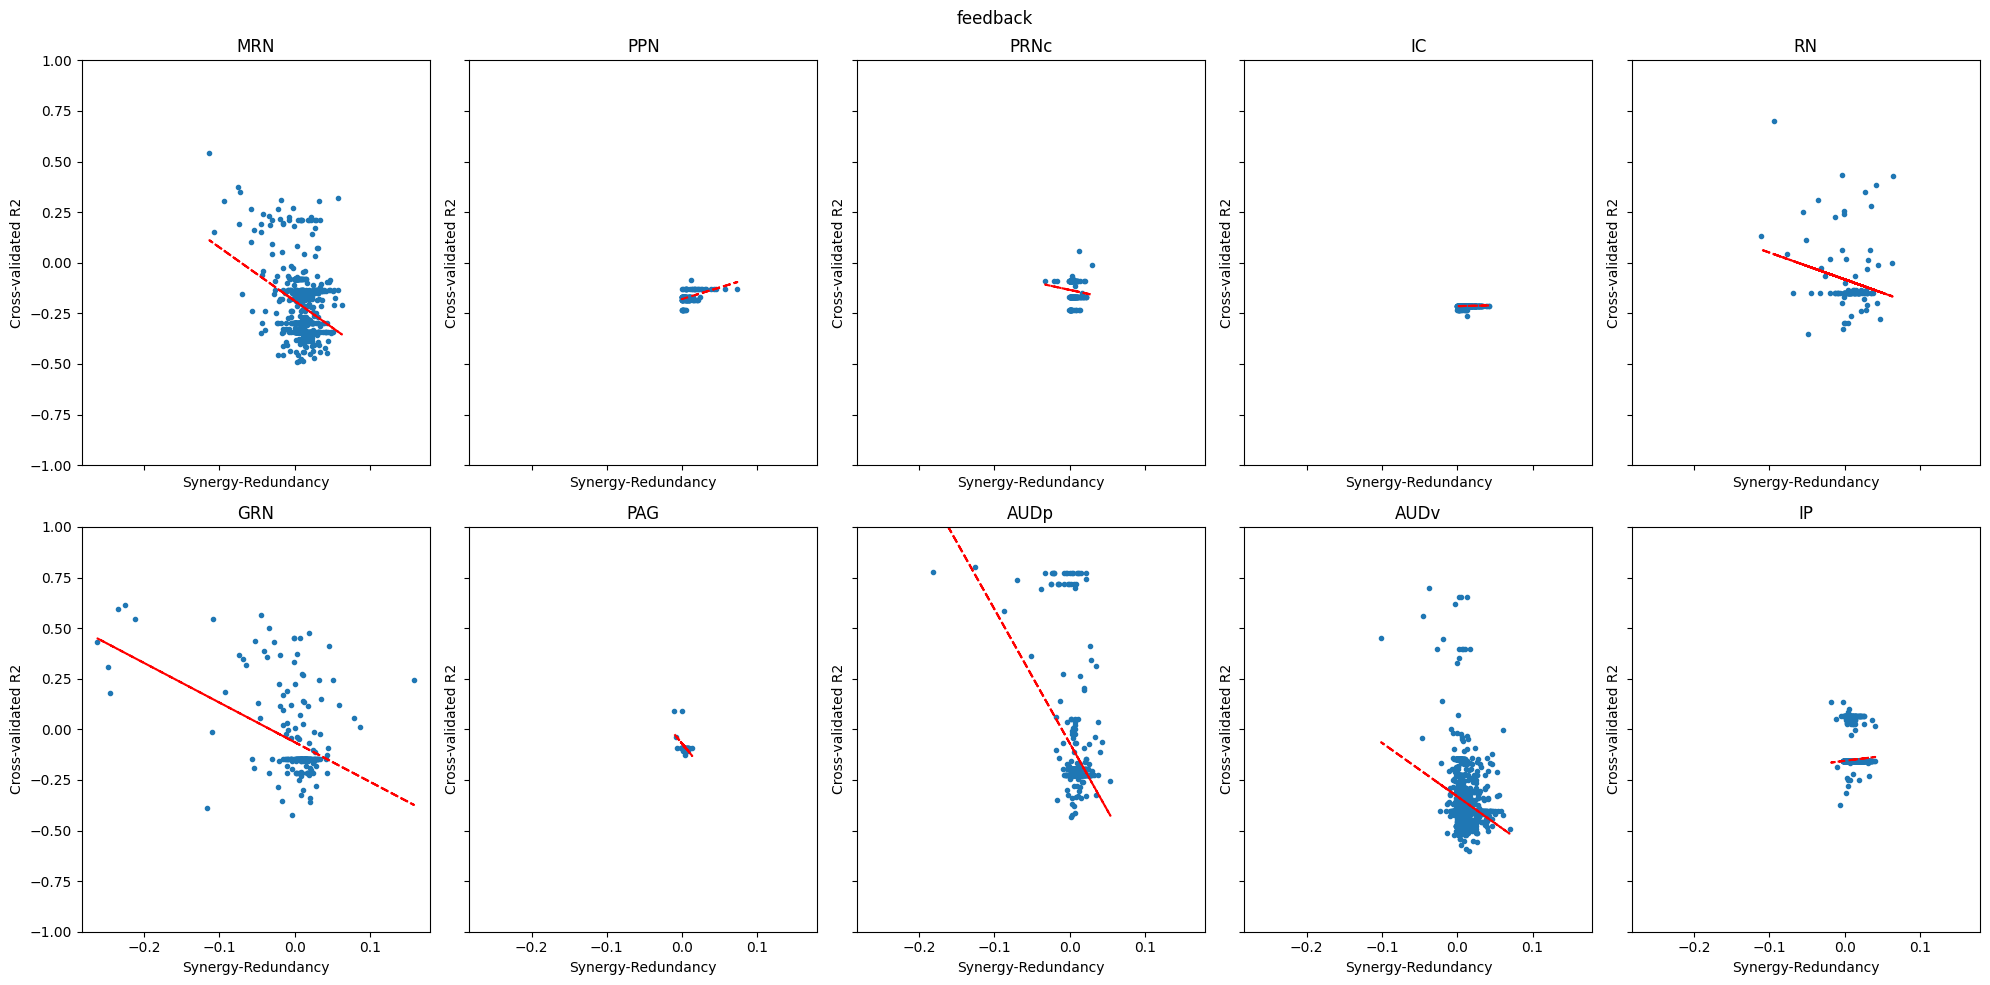

In [261]:
plot_epoch(list_of_eids, 'feedback', False)

In [308]:
# plot the same values for non-linear classifier
reduced_list = ['752456f3-9f47-4fbf-bd44-9d131c0f41aa', '5339812f-8b91-40ba-9d8f-a559563cc46b', '11163613-a6c9-4975-9586-84dc00481547', '16693458-0801-4d35-a3f1-9115c7e5acfd', '71855308-7e54-41d7-a7a4-b042e78e3b4f', 'ac7d3064-7f09-48a3-88d2-e86a4eb86461', 'aec5d3cc-4bb2-4349-80a9-0395b76f04e2', 'b182b754-3c3e-4942-8144-6ee790926b58', 'bb099402-fb31-4cfd-824e-1c97530a0875', 'c46b8def-620d-4d70-9397-be5694255f73', 'c958919c-2e75-435d-845d-5b62190b520e', '4a45c8ba-db6f-4f11-9403-56e06a33dfa4', '6b0b5d24-bcda-4053-a59c-beaa1fe03b8f', '07dc4b76-5b93-4a03-82a0-b3d9cc73f412', '7dd27c2f-9544-448d-918d-be0f9837b0e0', '7f5df7eb-cf36-4589-a20a-14b535441142', '8a3a0197-b40a-449f-be55-c00b23253bbf', '09b2c4d1-058d-4c84-9fd4-97530f85baf6', '9a629642-3a9c-42ed-b70a-532db0e86199', '56b57c38-2699-4091-90a8-aba35103155e', '63c70ae8-4dfb-418b-b21b-f0b1e5fba6c9', '97c1d08d-57b4-4595-8052-91eb84ebfd74', '239dd3c9-35f3-4462-95ee-91b822a22e6b', '810b1e07-009e-4ebe-930a-915e4cd8ece4', '872ce8ff-9fb3-485c-be00-bc5479e0095b', '5285c561-80da-4563-8694-739da92e5dd0', '5386aba9-9b97-4557-abcd-abc2da66b863', '6274dda8-3a59-4aa1-95f8-a8a549c46a26', '233617ec-c5cf-4eda-afc8-3b1d94f36d73']

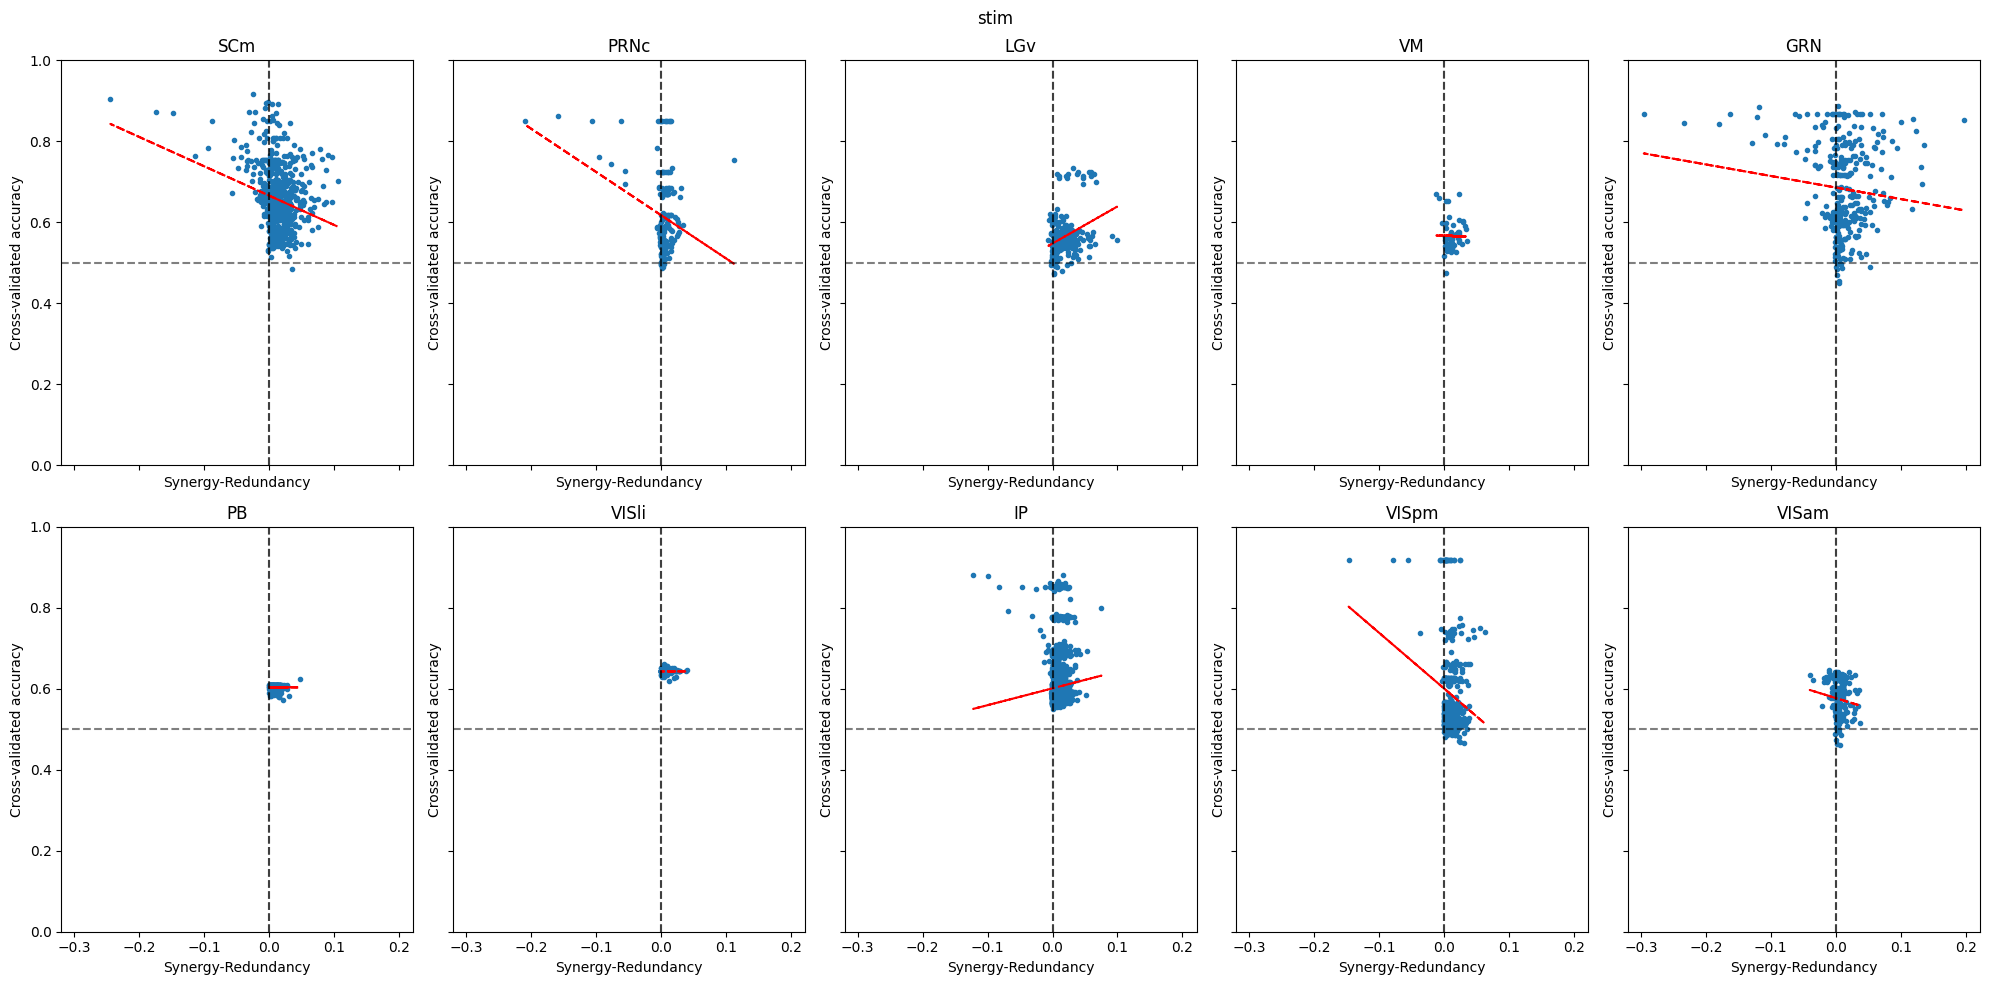

In [328]:
plot_epoch(list_of_eids, 'stim',False)